In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
%matplotlib inline

In [16]:
model= HookedTransformer.from_pretrained("gpt2")
model.eval()
print(f"Layers:{model.cfg.n_layers}")
print(f"Heads:{model.cfg.n_heads}")
print(f"d_model:{model.cfg.d_model}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2223.79it/s]


Loaded pretrained model gpt2 into HookedTransformer
Layers:12
Heads:12
d_model:768


In [17]:
sentence = "The sky is blue"
tokens = model.to_tokens(sentence)
str_tokens = model.to_str_tokens(sentence)
print("Token numbers:", tokens)
print("Token strings:", str_tokens)
print("Number of tokens:", len(str_tokens))

Token numbers: tensor([[50256,   464,  6766,   318,  4171]])
Token strings: ['<|endoftext|>', 'The', ' sky', ' is', ' blue']
Number of tokens: 5


In [18]:
def get_predictions(model, sentence, top_k=10):
    """
    Takes a sentence, runs it through GPT-2,
    returns the top_k most likely next tokens with their probabilities.
    """
    # Convert sentence to token numbers
    tokens = model.to_tokens(sentence)
    
    # Run through model, get output logits
    # logits shape: [1, sequence_length, vocab_size]
    # Think of it as: 1 sentence, N tokens, 50257 possible next words
    logits = model(tokens)
    
    # We only care about the LAST token's prediction
    # That's what comes next after our sentence
    last_logits = logits[0, -1, :]  # shape: [50257]
    
    # Convert logits to probabilities using softmax
    # Softmax makes all numbers positive and sum to 1
    probs = torch.softmax(last_logits, dim=-1)
    
    # Get the top_k highest probabilities and their indices
    top_probs, top_indices = torch.topk(probs, top_k)
    
    # Convert indices back to readable tokens
    top_tokens = [model.to_string(idx) for idx in top_indices]
    
    # Return as list of (token, probability) pairs
    return list(zip(top_tokens, top_probs.tolist()))

In [19]:
positive = "The sky is"
negative = "The sky is not"

print("After 'The sky is':")
for token, prob in get_predictions(model, positive, top_k=5):
    print(f"  '{token}': {prob:.3f}")

print("\nAfter 'The sky is not':")
for token, prob in get_predictions(model, negative, top_k=5):
    print(f"  '{token}': {prob:.3f}")

After 'The sky is':
  ' the': 0.212
  ' falling': 0.107
  ' blue': 0.066
  ' a': 0.062
  ' dark': 0.028

After 'The sky is not':
  ' the': 0.271
  ' falling': 0.106
  ' blue': 0.090
  ' always': 0.048
  ' a': 0.038


In [20]:
# Our test sentences - positive and negated versions
sentence_pairs = [
    ("The sky is", "The sky is not"),
    ("Fire is", "Fire is not"),
    ("Ice is", "Ice is not"),
    ("Honey is", "Honey is not"),
    ("She is happy", "She is not happy"),
    ("The room is dark", "The room is not dark"),
    ("The food is good", "The food is not good"),
    ("He is guilty", "He is not guilty"),
    ("The water is clean", "The water is not clean"),
    ("The answer is correct", "The answer is not correct"),
]

# Store results
overlap_scores = []

for pos, neg in sentence_pairs:
    pos_preds = get_predictions(model, pos, top_k=5)
    neg_preds = get_predictions(model, neg, top_k=5)
    
    # Get just the token strings (not probabilities)
    pos_tokens = set([t for t, p in pos_preds])
    neg_tokens = set([t for t, p in neg_preds])
    
    # How many tokens appear in both top-5 lists?
    overlap = len(pos_tokens.intersection(neg_tokens))
    overlap_scores.append(overlap)
    
    print(f"Positive: '{pos}' → top prediction: '{pos_preds[0][0]}'")
    print(f"Negative: '{neg}' → top prediction: '{neg_preds[0][0]}'")
    print(f"Overlap in top 5: {overlap}/5")
    print()

print(f"Average overlap: {np.mean(overlap_scores):.1f}/5")
print("(5/5 = model completely ignores 'not', 0/5 = model fully understands 'not')")

Positive: 'The sky is' → top prediction: ' the'
Negative: 'The sky is not' → top prediction: ' the'
Overlap in top 5: 4/5

Positive: 'Fire is' → top prediction: ' a'
Negative: 'Fire is not' → top prediction: ' a'
Overlap in top 5: 3/5

Positive: 'Ice is' → top prediction: ' a'
Negative: 'Ice is not' → top prediction: ' a'
Overlap in top 5: 3/5

Positive: 'Honey is' → top prediction: ' a'
Negative: 'Honey is not' → top prediction: ' a'
Overlap in top 5: 3/5

Positive: 'She is happy' → top prediction: ' to'
Negative: 'She is not happy' → top prediction: ' with'
Overlap in top 5: 3/5

Positive: 'The room is dark' → top prediction: ' and'
Negative: 'The room is not dark' → top prediction: ','
Overlap in top 5: 3/5

Positive: 'The food is good' → top prediction: ','
Negative: 'The food is not good' → top prediction: '.'
Overlap in top 5: 4/5

Positive: 'He is guilty' → top prediction: ' of'
Negative: 'He is not guilty' → top prediction: ' of'
Overlap in top 5: 4/5

Positive: 'The water is c

In [21]:
def measure_residual_difference(model, sentence_a, sentence_b):
    """
    Measures how different the residual stream is between two sentences
    at each layer, for the final token position.
    
    Returns a list of 12 numbers — one per layer.
    """
    tokens_a = model.to_tokens(sentence_a)
    tokens_b = model.to_tokens(sentence_b)
    
    # Run both sentences and get their internal caches
    _, cache_a = model.run_with_cache(tokens_a)
    _, cache_b = model.run_with_cache(tokens_b)
    
    differences = []
    
    for layer in range(model.cfg.n_layers):  # 0 to 11
        # Get residual stream AFTER this layer completes
        # Shape: [1, sequence_length, 768]
        resid_a = cache_a[f"blocks.{layer}.hook_resid_post"]
        resid_b = cache_b[f"blocks.{layer}.hook_resid_post"]
        
        # We want the LAST token position: [-1]
        # [0] is the batch dimension (we only have 1 sentence)
        last_a = resid_a[0, -1, :]  # shape: [768]
        last_b = resid_b[0, -1, :]  # shape: [768]
        
        # Calculate L2 norm of the difference
        # This measures "how far apart are these two vectors?"
        diff = (last_a - last_b).norm().item()
        differences.append(diff)
    
    return differences

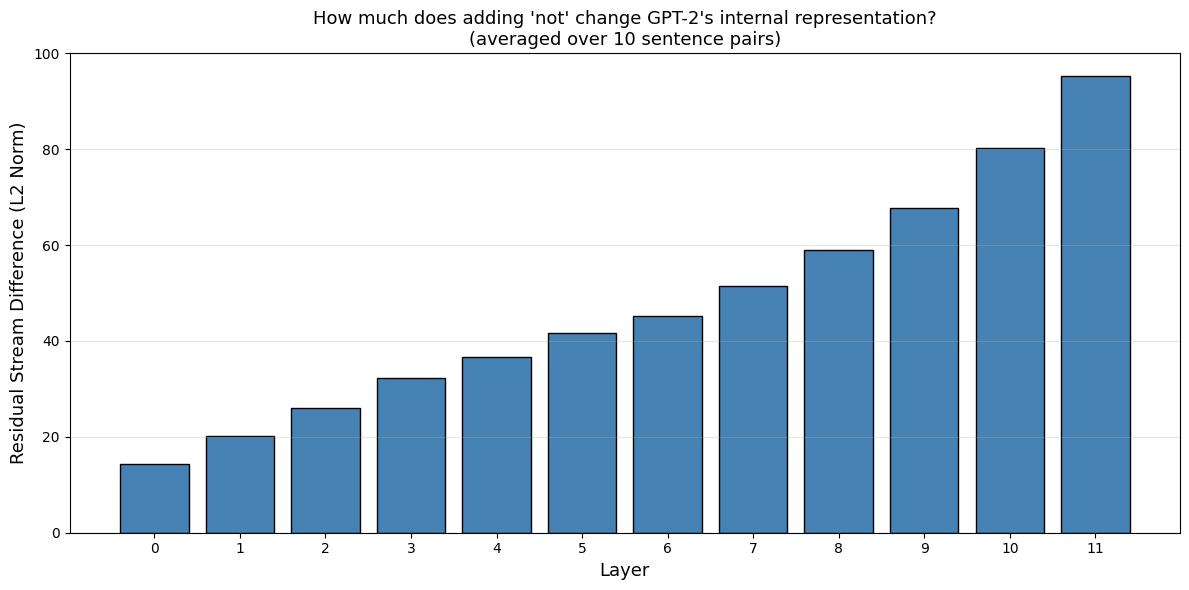

Differences by layer:
  Layer 0: 14.341
  Layer 1: 20.165
  Layer 2: 25.915
  Layer 3: 32.347
  Layer 4: 36.578
  Layer 5: 41.650
  Layer 6: 45.142
  Layer 7: 51.527
  Layer 8: 58.888
  Layer 9: 67.668
  Layer 10: 80.213
  Layer 11: 95.263


In [22]:
all_differences = []

for pos, neg in sentence_pairs:
    diffs = measure_residual_difference(model, pos, neg)
    all_differences.append(diffs)
    
# Average across all sentence pairs
avg_diffs = np.mean(all_differences, axis=0)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(12), avg_diffs, color='steelblue', edgecolor='black')
plt.xlabel("Layer", fontsize=13)
plt.ylabel("Residual Stream Difference (L2 Norm)", fontsize=13)
plt.title("How much does adding 'not' change GPT-2's internal representation?\n(averaged over 10 sentence pairs)", fontsize=13)
plt.xticks(range(12))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("residual_diff_by_layer.png", dpi=150)
plt.show()

print("Differences by layer:")
for layer, diff in enumerate(avg_diffs):
    print(f"  Layer {layer}: {diff:.3f}")

Found 'not' at position 4


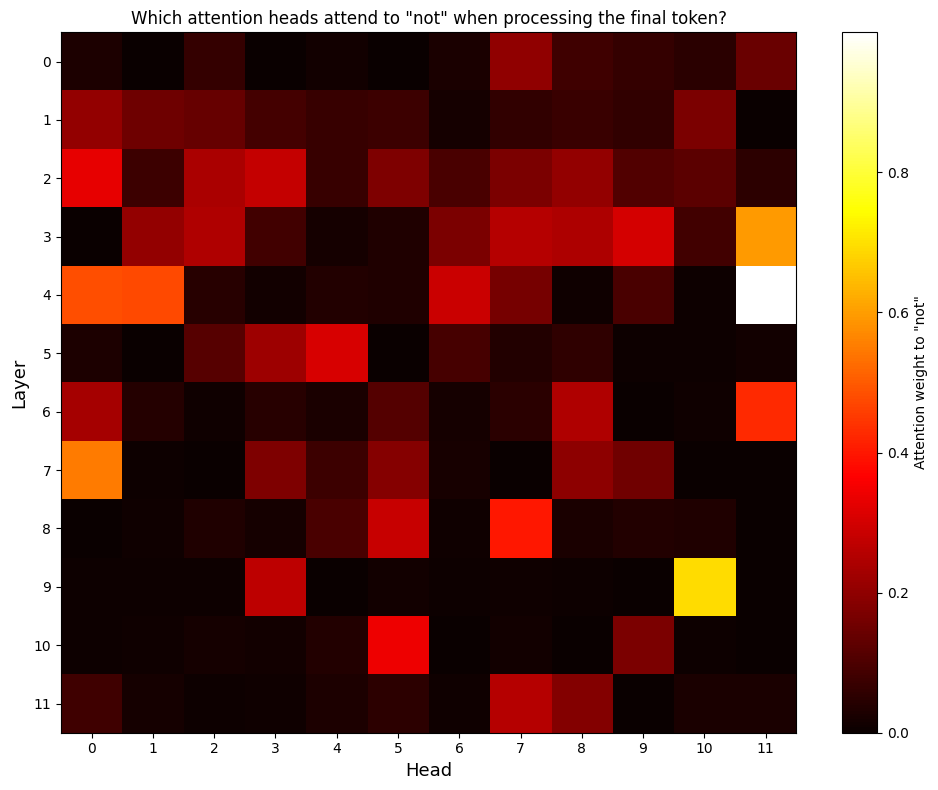

In [23]:
def get_attention_to_token(model, sentence, target_word):
    """
    For each layer and head, measures how much the LAST token
    attends to a specific word (like "not") in the sentence.
    
    Returns a 12x12 matrix (layers x heads).
    """
    tokens = model.to_tokens(sentence)
    str_tokens = model.to_str_tokens(sentence)
    
    # Find position of target word
    target_pos = None
    for i, tok in enumerate(str_tokens):
        if target_word.lower() in tok.lower():
            target_pos = i
            break
    
    if target_pos is None:
        print(f"'{target_word}' not found in: {str_tokens}")
        return None
    
    print(f"Found '{target_word}' at position {target_pos}")
    
    # Run model and get cache
    _, cache = model.run_with_cache(tokens)
    
    # attention_map[layer, head] = how much last token attends to target
    attention_map = np.zeros((12, 12))
    
    for layer in range(12):
        # cache["pattern", layer] shape: [1, n_heads, seq_len, seq_len]
        # [batch, head, destination_token, source_token]
        attn = cache["pattern", layer][0]  # remove batch dim
        
        for head in range(12):
            # attention from last token (-1) to target position
            attention_map[layer, head] = attn[head, -1, target_pos].item()
    
    return attention_map

# Test on one sentence
attn_map = get_attention_to_token(
    model, 
    "The sky is not blue", 
    "not"
)

# Plot as heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(attn_map, cmap='hot', aspect='auto', vmin=0)
plt.colorbar(im, label='Attention weight to "not"')
plt.xlabel("Head", fontsize=13)
plt.ylabel("Layer", fontsize=13)
plt.title('Which attention heads attend to "not" when processing the final token?', fontsize=12)
plt.xticks(range(12))
plt.yticks(range(12))
plt.tight_layout()
plt.savefig("attention_to_not_heatmap.png", dpi=150)
plt.show()

Found 'not' at position 4
Found 'not' at position 3
Found 'not' at position 3
Found 'not' at position 4
Found 'not' at position 3
Found 'not' at position 4
Found 'not' at position 4
Found 'not' at position 3
Found 'not' at position 4
Found 'not' at position 4


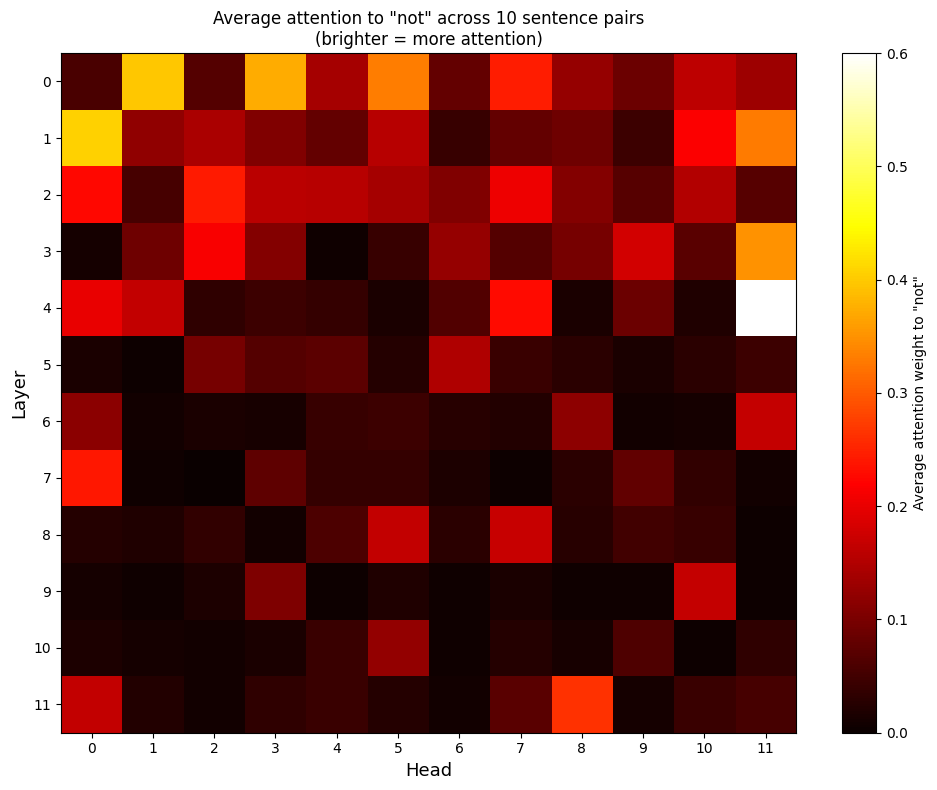

In [24]:
# Average attention to "not" across all negated sentences
all_attn_maps = []

for _, neg in sentence_pairs:
    attn = get_attention_to_token(model, neg, "not")
    if attn is not None:
        all_attn_maps.append(attn)

avg_attn_map = np.mean(all_attn_maps, axis=0)

plt.figure(figsize=(10, 8))
im = plt.imshow(avg_attn_map, cmap='hot', aspect='auto', vmin=0)
plt.colorbar(im, label='Average attention weight to "not"')
plt.xlabel("Head", fontsize=13)
plt.ylabel("Layer", fontsize=13)
plt.title('Average attention to "not" across 10 sentence pairs\n(brighter = more attention)', fontsize=12)
plt.xticks(range(12))
plt.yticks(range(12))
plt.tight_layout()
plt.savefig("attention_to_not_averaged.png", dpi=150)
plt.show()

In [25]:
# Control pairs - same extra token length, but NOT negation
control_pairs = [
    ("The sky is", "The sky is very"),
    ("Fire is", "Fire is quite"),
    ("She is happy", "She is very happy"),
    ("The room is dark", "The room is quite dark"),
    ("The water is clean", "The water is very clean"),
]

all_control_diffs = []
for pos, ctrl in control_pairs:
    diffs = measure_residual_difference(model, pos, ctrl)
    all_control_diffs.append(diffs)

avg_control_diffs = np.mean(all_control_diffs, axis=0)

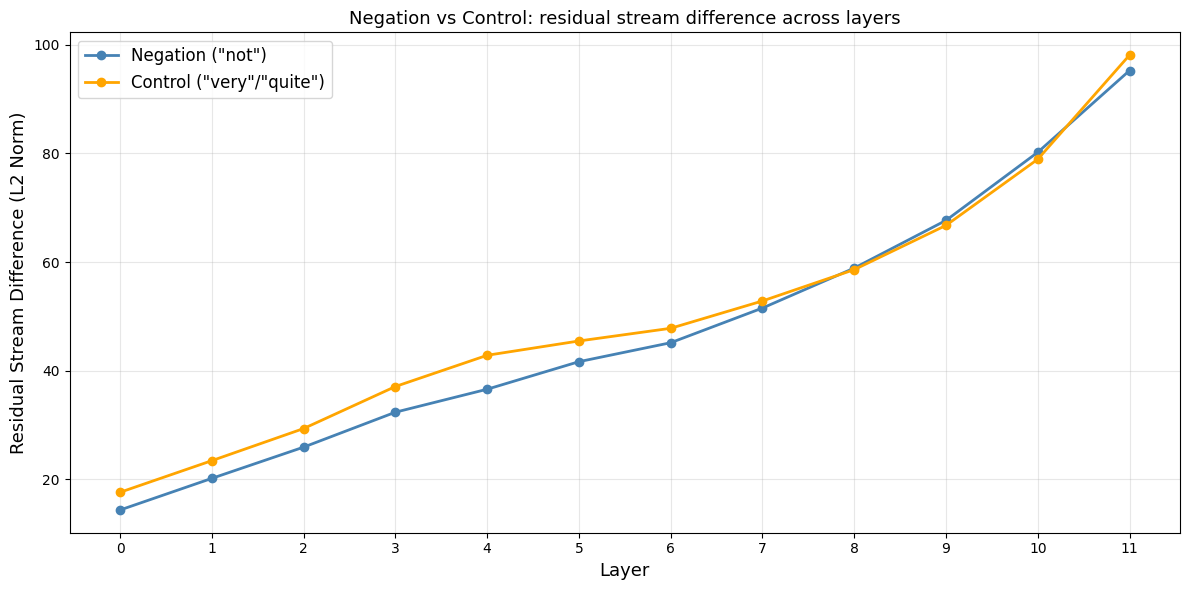

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(range(12), avg_diffs, 
         color='steelblue', marker='o', 
         linewidth=2, label='Negation ("not")')
plt.plot(range(12), avg_control_diffs, 
         color='orange', marker='o', 
         linewidth=2, label='Control ("very"/"quite")')
plt.xlabel("Layer", fontsize=13)
plt.ylabel("Residual Stream Difference (L2 Norm)", fontsize=13)
plt.title("Negation vs Control: residual stream difference across layers", fontsize=13)
plt.legend(fontsize=12)
plt.xticks(range(12))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("negation_vs_control.png", dpi=150)
plt.show()

In [27]:
print("Layer | Negation | Control | Difference")
print("-" * 45)
for layer in range(12):
    neg = avg_diffs[layer]
    ctrl = avg_control_diffs[layer]
    diff = neg - ctrl
    print(f"Layer {layer:2d} | {neg:8.3f} | {ctrl:8.3f} | {diff:+.3f}")

Layer | Negation | Control | Difference
---------------------------------------------
Layer  0 |   14.341 |   17.602 | -3.261
Layer  1 |   20.165 |   23.425 | -3.260
Layer  2 |   25.915 |   29.339 | -3.424
Layer  3 |   32.347 |   37.078 | -4.731
Layer  4 |   36.578 |   42.829 | -6.251
Layer  5 |   41.650 |   45.463 | -3.813
Layer  6 |   45.142 |   47.798 | -2.657
Layer  7 |   51.527 |   52.832 | -1.304
Layer  8 |   58.888 |   58.601 | +0.288
Layer  9 |   67.668 |   66.749 | +0.919
Layer 10 |   80.213 |   78.929 | +1.284
Layer 11 |   95.263 |   98.111 | -2.848
